In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
    

from src.config import PROCESSED_DATA_DIR
from src.utils.plots import save_figure, style_plot, create_figure, add_bar_labels, add_source, YOUTUBE_RED
import pandas as pd


Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/category-distribution.png


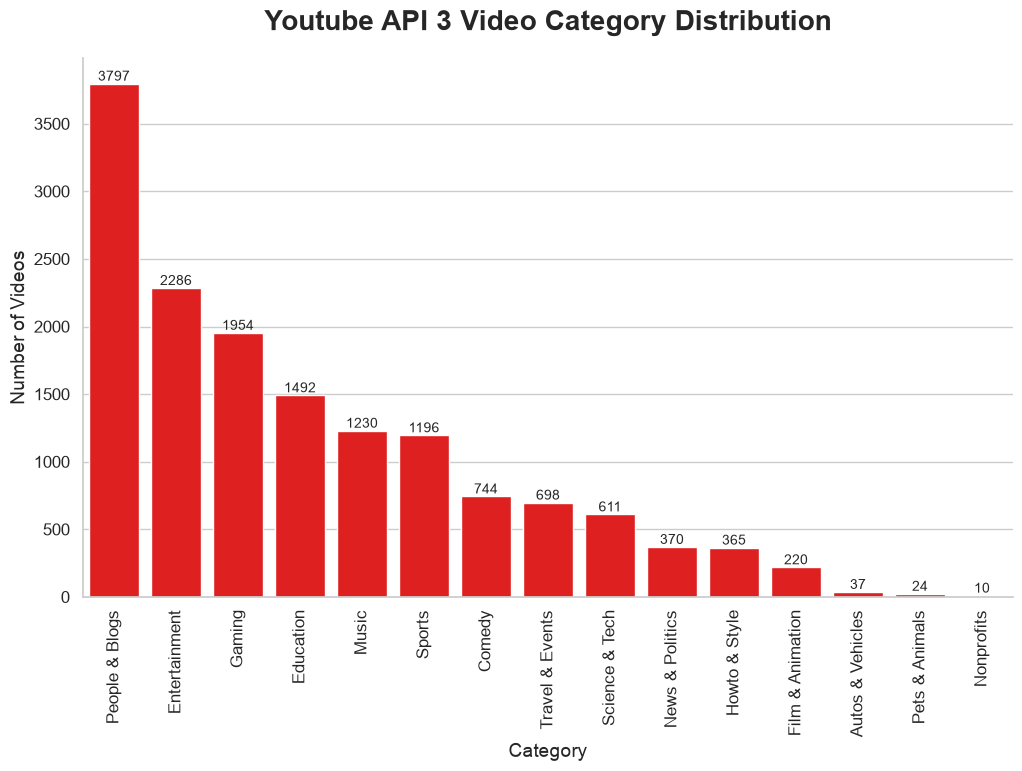

<Figure size 640x480 with 0 Axes>

In [4]:
df = pd.read_csv(PROCESSED_DATA_DIR / "youtube_clean.csv")


# category distribution
category_counts = (
    df["category_name"]
    .value_counts()
    .sort_values(ascending=False)
)


fig, ax = create_figure()
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=ax,
    color=YOUTUBE_RED
)
ax.tick_params(axis="x", rotation=90)

style_plot(ax=ax, xlabel='Category', ylabel='Number of Videos', title="Youtube API 3 Video Category Distribution")
add_bar_labels(ax)
save_figure(fig=fig,  filename='q1/category-distribution.png')
plt.show()
plt.clf()



In [3]:
# category performance
category_summary = (
    df.groupby("category_name")
    .agg(
        videos=("video_id", "count"),
        mean_views=("views", "mean"),
        median_views=("views", "median"),
        mean_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        mean_comments=("comments", "mean"),
        median_comments=("comments", "median"),
        mean_engagement=("engagement_rate", "mean"),
        median_engagement=("engagement_rate", "median")
    )
    .sort_values("mean_engagement", ascending=False)
)


category_summary

,videos,mean_views,median_views,mean_likes,median_likes,mean_comments,median_comments,mean_engagement,median_engagement
category_name,,,,,,,,,
News & Politics,297,4.621392e+05,24561.0,7249.973064,439.0,505.397306,28.0,0.046258,0.016300
Pets & Animals,21,2.290920e+07,2511788.0,505059.142857,41745.0,2199.619048,260.0,0.042979,0.025791
Gaming,1637,3.061143e+06,306685.0,59014.177764,6605.0,1620.344533,351.0,0.033882,0.026599
Science & Tech,538,7.608765e+06,713025.0,175257.927509,17040.0,2074.942379,500.0,0.028977,0.026014
People & Blogs,3215,7.292590e+06,331966.0,112119.795645,4453.0,1025.846967,56.0,0.025681,0.017468
Nonprofits,8,5.722812e+06,225411.5,82291.375000,5295.5,320.500000,34.0,0.025516,0.016476
Education,1316,1.479277e+07,346781.0,78337.914894,4864.0,1077.459726,44.0,0.024570,0.018796
Howto & Style,306,2.475141e+07,724054.5,328252.248366,11484.5,1150.333333,144.0,0.024213,0.017521
Autos & Vehicles,32,8.429666e+06,387664.5,75536.375000,2148.5,669.593750,83.5,0.022395,0.017362


Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/mean_engagement_by_category.png


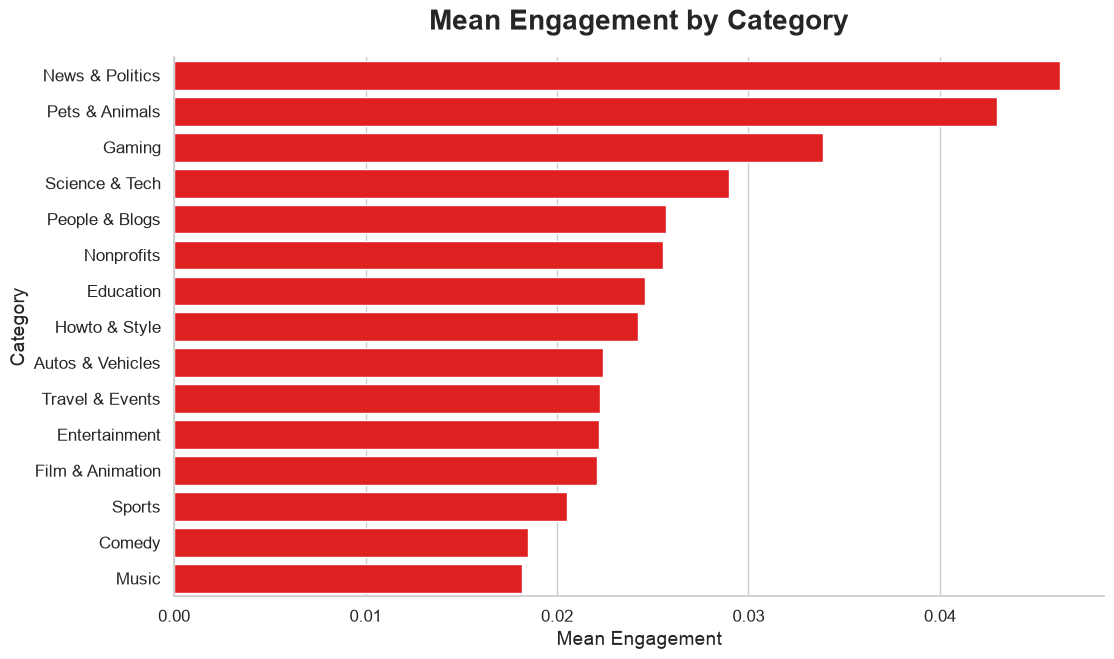

<Figure size 640x480 with 0 Axes>

In [4]:

fig, ax = create_figure()
sns.barplot(
    data=category_summary,
    x="mean_engagement",
    y="category_name",
    color=YOUTUBE_RED
)

style_plot(ax=ax, xlabel='Mean Engagement', ylabel='Category', title="Mean Engagement by Category")
save_figure(fig=fig, filename='q1/mean_engagement_by_category.png')

plt.show()
plt.clf()

In [5]:

metrics = (
    df.groupby("category_name")
    .agg({
        "likes":"mean",
        "comments":"mean",
        "engagement_rate":"mean",
        "views":"mean"
    })
)

metrics.idxmax()

likes                        Music
comments                     Music
engagement_rate    News & Politics
views                        Music
dtype: str

Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/engagement_rate_by_category.png


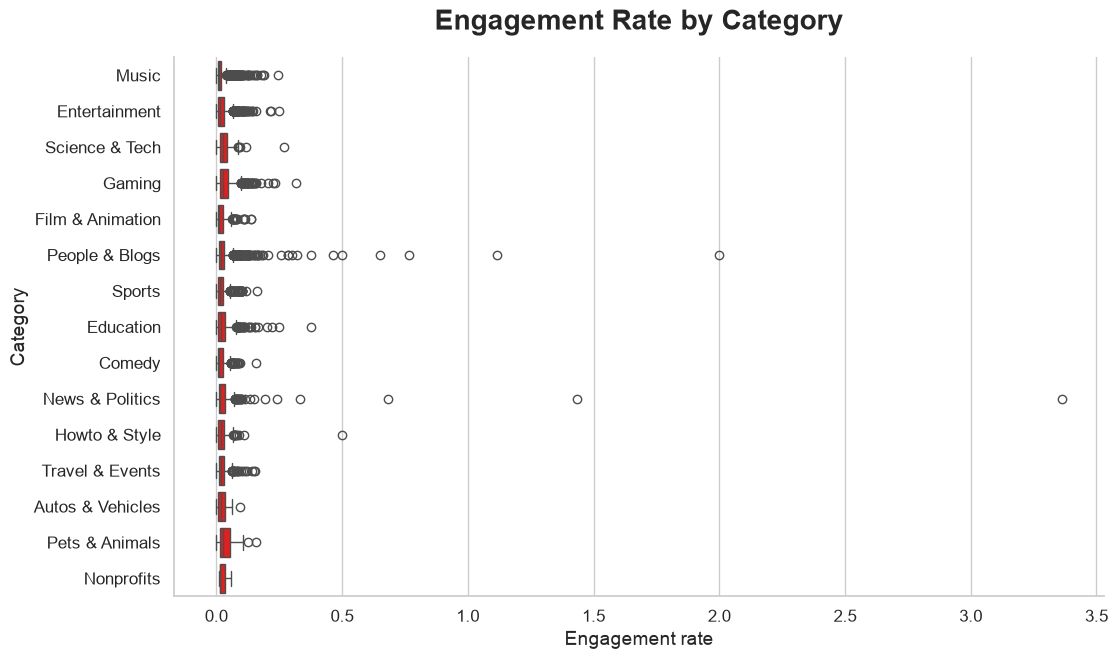

<Figure size 640x480 with 0 Axes>

In [12]:

fig, ax = create_figure()
sns.boxplot(
    data=df,
    x="engagement_rate",
    y="category_name",
    color=YOUTUBE_RED
)

style_plot(ax=ax, ylabel='Category', xlabel="Engagement rate", title="Engagement Rate by Category")
save_figure(fig=fig, filename='q1/engagement_rate_by_category.png')

plt.show()
plt.clf()